## CIS 585 Project
### Text-Conditional Latent Diffusion Model
##### Name: Yash Dave (daveyash@umich.edu)

### Import training and testing scripts and define configs

In [2]:
import warnings
warnings.filterwarnings("ignore")

from tools.train_vqvae import *
from tools.infer_vqvae import *
from tools.train_ddpm_cond import *
from tools.sample_ddpm_text_cond import *

config_path = "./config/celebhq.yaml"
ddpm_config = "./config/celebhq_text_cond.yaml"

Using device: mps
Using device: mps


### Train Vector Quantized Variational Auto-Encoder (VQ-VAE) 

In [ ]:

train_vqvae(config_path)

{'dataset_params': {'im_path': 'data/CelebAMask-HQ', 'im_channels': 3, 'im_size': 256, 'name': 'celebhq'}, 'diffusion_params': {'num_timesteps': 1000, 'beta_start': 0.0015, 'beta_end': 0.0195}, 'ldm_params': {'down_channels': [256, 384, 512, 768], 'mid_channels': [768, 512], 'down_sample': [True, True, True], 'attn_down': [True, True, True], 'time_emb_dim': 512, 'norm_channels': 32, 'num_heads': 16, 'conv_out_channels': 128, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'autoencoder_params': {'z_channels': 4, 'codebook_size': 8192, 'down_channels': [64, 128, 256, 256], 'mid_channels': [256, 256], 'down_sample': [True, True, True], 'attn_down': [False, False, False], 'norm_channels': 32, 'num_heads': 4, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'train_params': {'seed': 1111, 'task_name': 'celebhq', 'ldm_batch_size': 32, 'autoencoder_batch_size': 4, 'disc_start': 15000, 'disc_weight': 0.5, 'codebook_weight': 1, 'commitment_beta': 0.2, 'perceptual_w

100%|██████████| 100/100 [00:00<00:00, 418175.87it/s]

Found 100 images
Found 0 masks
Found 0 captions


Loading model from: /Users/yashdave/Documents/MSc/CIS585/Project/CIS585-project/models/weights/v0.1/vgg.pth


  0%|          | 0/25 [00:11<?, ?it/s]


KeyboardInterrupt: 

### Test Vector Quantized Variational Auto-Encoder (VQ-VAE) 

{'dataset_params': {'im_path': 'data/CelebAMask-HQ', 'im_channels': 3, 'im_size': 256, 'name': 'celebhq'}, 'diffusion_params': {'num_timesteps': 1000, 'beta_start': 0.0015, 'beta_end': 0.0195}, 'ldm_params': {'down_channels': [256, 384, 512, 768], 'mid_channels': [768, 512], 'down_sample': [True, True, True], 'attn_down': [True, True, True], 'time_emb_dim': 512, 'norm_channels': 32, 'num_heads': 16, 'conv_out_channels': 128, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'autoencoder_params': {'z_channels': 4, 'codebook_size': 8192, 'down_channels': [64, 128, 256, 256], 'mid_channels': [256, 256], 'down_sample': [True, True, True], 'attn_down': [False, False, False], 'norm_channels': 32, 'num_heads': 4, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'train_params': {'seed': 1111, 'task_name': 'celebhq', 'ldm_batch_size': 32, 'autoencoder_batch_size': 4, 'disc_start': 15000, 'disc_weight': 0.5, 'codebook_weight': 1, 'commitment_beta': 0.2, 'perceptual_w

100%|██████████| 100/100 [00:00<00:00, 1514189.17it/s]

Found 100 images
Found 0 masks
Found 0 captions


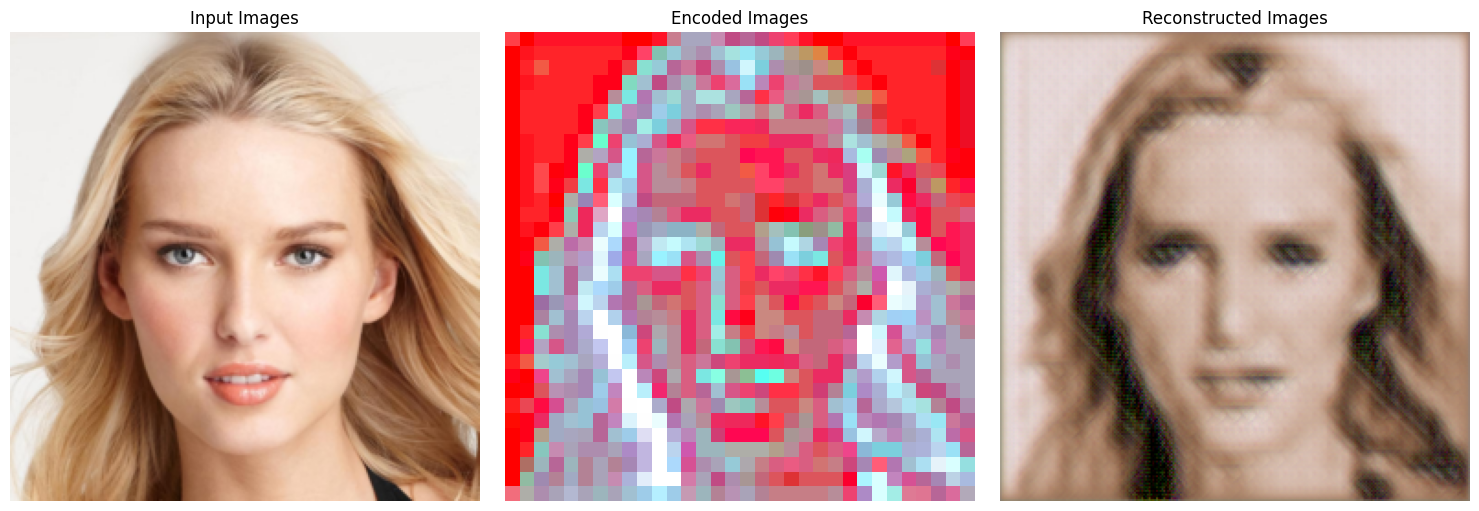

Saving Latents for celebhq


100%|██████████| 100/100 [00:08<00:00, 12.25it/s]

Done saving latents


In [ ]:
infer_vqvae(config_path)

### Train Text Conditional Latent Diffusion Model 

Using device: mps
{'dataset_params': {'im_path': 'data/CelebAMask-HQ', 'im_channels': 3, 'im_size': 256, 'name': 'celebhq'}, 'diffusion_params': {'num_timesteps': 1000, 'beta_start': 0.00085, 'beta_end': 0.012}, 'ldm_params': {'down_channels': [256, 384, 512, 768], 'mid_channels': [768, 512], 'down_sample': [True, True, True], 'attn_down': [True, True, True], 'time_emb_dim': 512, 'norm_channels': 32, 'num_heads': 16, 'conv_out_channels': 128, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2, 'condition_config': {'condition_types': ['text'], 'text_condition_config': {'text_embed_model': 'clip', 'train_text_embed_model': False, 'text_embed_dim': 512, 'cond_drop_prob': 0.1}}}, 'autoencoder_params': {'z_channels': 4, 'codebook_size': 8192, 'down_channels': [64, 128, 256, 256], 'mid_channels': [256, 256], 'down_sample': [True, True, True], 'attn_down': [False, False, False], 'norm_channels': 32, 'num_heads': 4, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'tr

100%|██████████| 100/100 [00:00<00:00, 7094.80it/s]


Found 100 images
Found 0 masks
Found 100 captions
Found 100 latents


100%|██████████| 7/7 [05:54<00:00, 50.63s/it]


Finished epoch:1 | Loss : 1.0779


...

Finished epoch:18 | Loss : 0.5026


100%|██████████| 7/7 [08:20<00:00, 71.49s/it]


Finished epoch:19 | Loss : 0.4747


100%|██████████| 7/7 [08:45<00:00, 75.07s/it] 


Finished epoch:20 | Loss : 0.4677


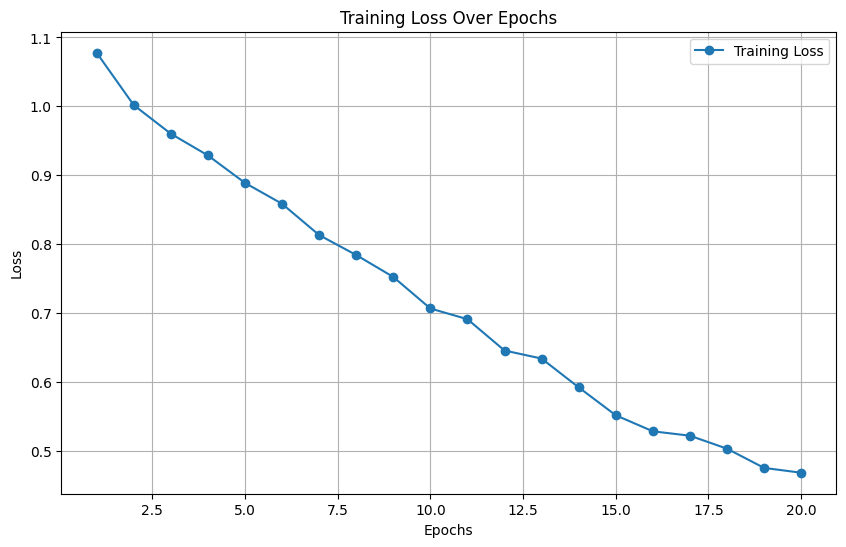

Done Training ...


In [ ]:
train_ddpm(ddpm_config)

### Train Text Conditional Latent Diffusion Model 

{'dataset_params': {'im_path': 'data/CelebAMask-HQ', 'im_channels': 3, 'im_size': 256, 'name': 'celebhq'}, 'diffusion_params': {'num_timesteps': 1000, 'beta_start': 0.00085, 'beta_end': 0.012}, 'ldm_params': {'down_channels': [256, 384, 512, 768], 'mid_channels': [768, 512], 'down_sample': [True, True, True], 'attn_down': [True, True, True], 'time_emb_dim': 512, 'norm_channels': 32, 'num_heads': 16, 'conv_out_channels': 128, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2, 'condition_config': {'condition_types': ['text'], 'text_condition_config': {'text_embed_model': 'clip', 'train_text_embed_model': False, 'text_embed_dim': 512, 'cond_drop_prob': 0.1}}}, 'autoencoder_params': {'z_channels': 4, 'codebook_size': 8192, 'down_channels': [64, 128, 256, 256], 'mid_channels': [256, 256], 'down_sample': [True, True, True], 'attn_down': [False, False, False], 'norm_channels': 32, 'num_heads': 4, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'train_params': {'see

1000it [02:07,  7.84it/s]


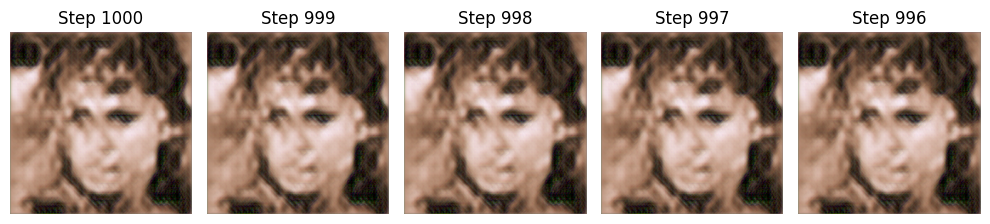

In [4]:
text_prompt = ['He is a man with long blonde hairs']
infer_ddpm(ddpm_config, text_prompt)